WHO-Style Influenza Threshold Calculation

This document describes a WHO-style approach for calculating influenza surveillance thresholds using historical weekly influenza activity data.

Note: This is the statistical implementation used in this example. The exact WHO protocol/version should be cited if presenting it as an official WHO implementation.

1. Historical Data

Use several years of weekly influenza surveillance data with the same indicator across all years.

Example indicators
ILI cases per 1,000 population
Influenza positivity (%)

The indicator should be consistently defined and measured across all historical years.

2. Identify Peak Week

For each year, identify the week with the highest influenza activity.

Formula

Peak Week
=
arg⁡max⁡𝑤
(
Activity
𝑤
)

Where:

$w$ = epidemiological week
$\text{Activity}_w$ = influenza activity during week $w$

Interpretation: The peak week is the week in which influenza activity reaches its maximum for that year.

3. Calculate Median Peak Week

Calculate the median of all historical peak weeks.

Formula

Median Peak Week
=
median
⁡
(
Peak Week
1
,
Peak Week
2
,
…
,
Peak Week
𝑛
)

Where:

$n$ = number of historical seasons
$\text{Peak Week}_i$ = peak week for historical season $i$

Purpose: The median peak week provides a common reference point for aligning different influenza seasons.

4. Align Historical Seasons

Shift each historical season so that its peak occurs at the median peak week.

Concept

For each historical season:

Aligned Week
=
Original Week
+
(
Median Peak Week
−
Season Peak Week
)

This alignment allows equivalent phases of different influenza seasons to be compared.

5. Calculate Mean and Standard Deviation

For each aligned week, calculate the historical mean and standard deviation of influenza activity.

Mean

Mean
𝑤
=
1
𝑛
∑
𝑖
=
1
𝑛
𝑋
𝑖
,
𝑤

Where:

$X_{i,w}$ = influenza activity for season $i$ at aligned week $w$
$n$ = number of historical seasons
$\text{Mean}_w$ = average activity at aligned week $w$

Mean → typical influenza activity

Standard Deviation

SD
𝑤
=
1
𝑛
−
1
∑
𝑖
=
1
𝑛
(
𝑋
𝑖
,
𝑤
−
Mean
𝑤
)
2

SD → variability between historical seasons

6. Average Threshold

The average threshold is defined as the maximum value of the historical mean activity curve.

Formula

Average Threshold
=
max
⁡
𝑤
(
Mean
𝑤
)

Interpretation: This represents the typical peak level of historical influenza activity.

7. Alert Threshold

The upper statistical boundary is calculated for each aligned week.

Formula

Upper Boundary
𝑤
=
Mean
𝑤
+
1.645
×
SD
𝑤

Where:

1.645
=
one-sided 90% normal quantile

Interpretation
Mean → typical influenza activity
SD → variability between seasons
Mean + 1.645 × SD → upper statistical boundary
Activity above the relevant boundary indicates unusually high influenza activity

Important: The exact calculation and interpretation of an alert threshold may depend on the specific WHO methodology/version being implemented. Cite the relevant WHO protocol when presenting this as an official WHO implementation.

8. Seasonal Threshold

The seasonal threshold identifies the transition from background activity to the influenza season.

It can be estimated from historical out-of-season observations.

Formula

Seasonal Threshold
=
𝑃
95
(
Out-of-Season Activity
)

Where:

$P_{95}$ = 95th percentile
Out-of-season activity = historical influenza activity observed outside the defined influenza seasons

Interpretation: Activity above this threshold may indicate the transition from background activity into the influenza season.

9. Classify Predictions

Predicted or observed influenza activity is compared against the calculated thresholds.

Activity Level	Interpretation
$< \text{Seasonal Threshold}$	Below seasonal
$\text{Seasonal Threshold} \rightarrow \text{Average Threshold}$	Seasonal activity
$\text{Average Threshold} \rightarrow \text{Alert Threshold}$	Elevated activity
$\geq \text{Alert Threshold}$	🚨 ALERT
Classification Logic

{
𝑋
<
𝑇
seasonal
	
→
Below Seasonal


𝑇
seasonal
≤
𝑋
<
𝑇
average
	
→
Seasonal Activity


𝑇
average
≤
𝑋
<
𝑇
alert
	
→
Elevated Activity


𝑋
≥
𝑇
alert
	
→
ALERT

Where:

$X$ = observed or predicted influenza activity
$T_{\text{seasonal}}$ = seasonal threshold
$T_{\text{average}}$ = average threshold
$T_{\text{alert}}$ = alert threshold
10. Overall Logic

The complete methodology can be summarized as:

Historical Data
→
Peak Weeks
→
Season Alignment
→
Mean + SD
→
Thresholds
→
Forecast
→
Threshold Comparison
→
Alert

Step-by-Step Workflow

Collect historical data

Weekly influenza surveillance data
Same indicator across all historical years

Identify peak weeks

Find the maximum activity for each season.

Calculate median peak week

Establish a common seasonal reference point.

Align historical seasons

Shift each season so that its peak aligns with the median peak week.

Calculate statistical curves

Mean activity for each aligned week
Standard deviation for each aligned week

Calculate thresholds

Average threshold
Alert / upper statistical boundary
Seasonal threshold

Generate predictions

Produce forecasted influenza activity.

Compare predictions with thresholds

Determine the corresponding activity category.

Generate alert

Trigger an alert when activity reaches or exceeds the alert threshold.
Reference

Tay, E. L., et al. (2013).
Exploring a Proposed WHO Method to Determine Thresholds for Seasonal Influenza Surveillance.

https://pmc.ncbi.nlm.nih.gov/articles/PMC3795663/

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# ============================================================
# 1. CREATE DUMMY HISTORICAL INFLUENZA DATA
# ============================================================

np.random.seed(42)

years = range(2018, 2025)
weeks = np.arange(1, 53)

historical_data = []

for year in years:

    # Randomize the peak week for each season
    peak_week = np.random.randint(30, 37)

    for week in weeks:

        # Gaussian-shaped influenza epidemic curve
        baseline = 1.0

        epidemic = (
            15
            * np.exp(-0.5 * ((week - peak_week) / 4.0) ** 2)
        )

        noise = np.random.normal(0, 0.8)

        value = max(0, baseline + epidemic + noise)

        historical_data.append({
            "year": year,
            "week": week,
            "value": value
        })


historical = pd.DataFrame(historical_data)

In [3]:

# ============================================================
# 2. FIND THE PEAK WEEK FOR EACH YEAR
# ============================================================

peak_weeks = (
    historical
    .loc[historical.groupby("year")["value"].idxmax()]
    .sort_values("year")
)

print("Peak week for each historical season:")
print(peak_weeks[["year", "week", "value"]])

Peak week for each historical season:
     year  week      value
35   2018    36  15.717507
86   2019    35  15.939657
137  2020    34  16.022885
187  2021    32  18.176135
239  2022    32  16.210503
291  2023    32  16.239902
345  2024    34  16.428821


In [4]:

# ============================================================
# 3. DETERMINE THE MEDIAN PEAK WEEK
# ============================================================

median_peak_week = int(
    np.median(peak_weeks["week"])
)

print("\nMedian peak week:", median_peak_week)


Median peak week: 34


In [5]:
# ============================================================
# 4. ALIGN ALL HISTORICAL SEASONS
# ============================================================

aligned_data = []

for year in historical["year"].unique():

    year_data = historical[
        historical["year"] == year
    ].copy()

    # Peak week for this year
    peak_week = int(
        peak_weeks.loc[
            peak_weeks["year"] == year,
            "week"
        ].iloc[0]
    )

    # Shift so that every season peaks at median_peak_week
    shift = median_peak_week - peak_week

    year_data["aligned_week"] = (
        year_data["week"] + shift
    )

    aligned_data.append(year_data)


aligned = pd.concat(
    aligned_data,
    ignore_index=True
)

In [6]:

# ============================================================
# 5. CALCULATE WEEKLY MEAN AND STANDARD DEVIATION
# ============================================================

weekly_stats = (
    aligned
    .groupby("aligned_week")["value"]
    .agg(["mean", "std"])
    .reset_index()
)

weekly_stats.rename(
    columns={
        "mean": "historical_mean",
        "std": "historical_sd"
    },
    inplace=True
)

In [7]:

# ============================================================
# 6. CALCULATE AVERAGE THRESHOLD
# ============================================================

# WHO-style approach:
# Average threshold = peak of the mean epidemic curve

average_threshold = weekly_stats[
    "historical_mean"
].max()

print("\nAverage threshold:")
print(round(average_threshold, 2))


Average threshold:
16.39


In [8]:

# ============================================================
# 7. CALCULATE ALERT THRESHOLD
# ============================================================

# Approximate upper 90% confidence boundary.
#
# IMPORTANT:
# Depending on the exact WHO implementation,
# this can be calculated using the upper confidence
# limit of the historical distribution.
#
# Here we use:
#
#       mean + 1.645 * SD
#
# at each aligned week.

weekly_stats["alert_curve"] = (
    weekly_stats["historical_mean"]
    + 1.645 * weekly_stats["historical_sd"]
)


# Alert threshold = maximum of the upper confidence curve

alert_threshold = weekly_stats[
    "alert_curve"
].max()

print("\nAlert threshold:")
print(round(alert_threshold, 2))


Alert threshold:
17.74


In [9]:

# ============================================================
# 8. DETERMINE SEASONAL THRESHOLD
# ============================================================

# For demonstration we use the upper baseline level
# outside the influenza season.
#
# A real WHO implementation should determine this
# from the actual out-of-season historical observations.

# Define out-of-season weeks
out_of_season = aligned[
    (aligned["aligned_week"] < median_peak_week - 10)
    |
    (aligned["aligned_week"] > median_peak_week + 10)
]

seasonal_threshold = np.percentile(
    out_of_season["value"],
    95
)

print("\nSeasonal threshold:")
print(round(seasonal_threshold, 2))



Seasonal threshold:
2.48


In [10]:
# ============================================================
# 9. CREATE DUMMY FUTURE / PREDICTED VALUES
# ============================================================

future_weeks = np.arange(1, 53)

# Dummy prediction with a slightly larger epidemic
prediction = (
    1
    + 18
    * np.exp(
        -0.5
        * ((future_weeks - 34) / 4.5) ** 2
    )
)

# Add prediction noise
prediction += np.random.normal(
    0,
    0.5,
    len(future_weeks)
)

prediction = np.maximum(
    prediction,
    0
)


predicted = pd.DataFrame({
    "week": future_weeks,
    "prediction": prediction
})

In [11]:
# ============================================================
# 10. CLASSIFY PREDICTION ACCORDING TO THRESHOLDS
# ============================================================

def classify_activity(value):

    if value < seasonal_threshold:
        return "Below seasonal"

    elif value < average_threshold:
        return "Seasonal"

    elif value < alert_threshold:
        return "Average / elevated"

    else:
        return "ALERT"


predicted["status"] = predicted[
    "prediction"
].apply(classify_activity)

In [12]:
# ============================================================
# 11. PRINT ALERT WEEKS
# ============================================================

alert_weeks = predicted[
    predicted["status"] == "ALERT"
]

print("\nPredicted ALERT weeks:")

if len(alert_weeks) > 0:
    print(
        alert_weeks[
            ["week", "prediction", "status"]
        ].to_string(index=False)
    )
else:
    print("No alert predicted.")


Predicted ALERT weeks:
 week  prediction status
   33   18.213925  ALERT
   34   19.054930  ALERT
   35   18.732226  ALERT
   36   18.262958  ALERT


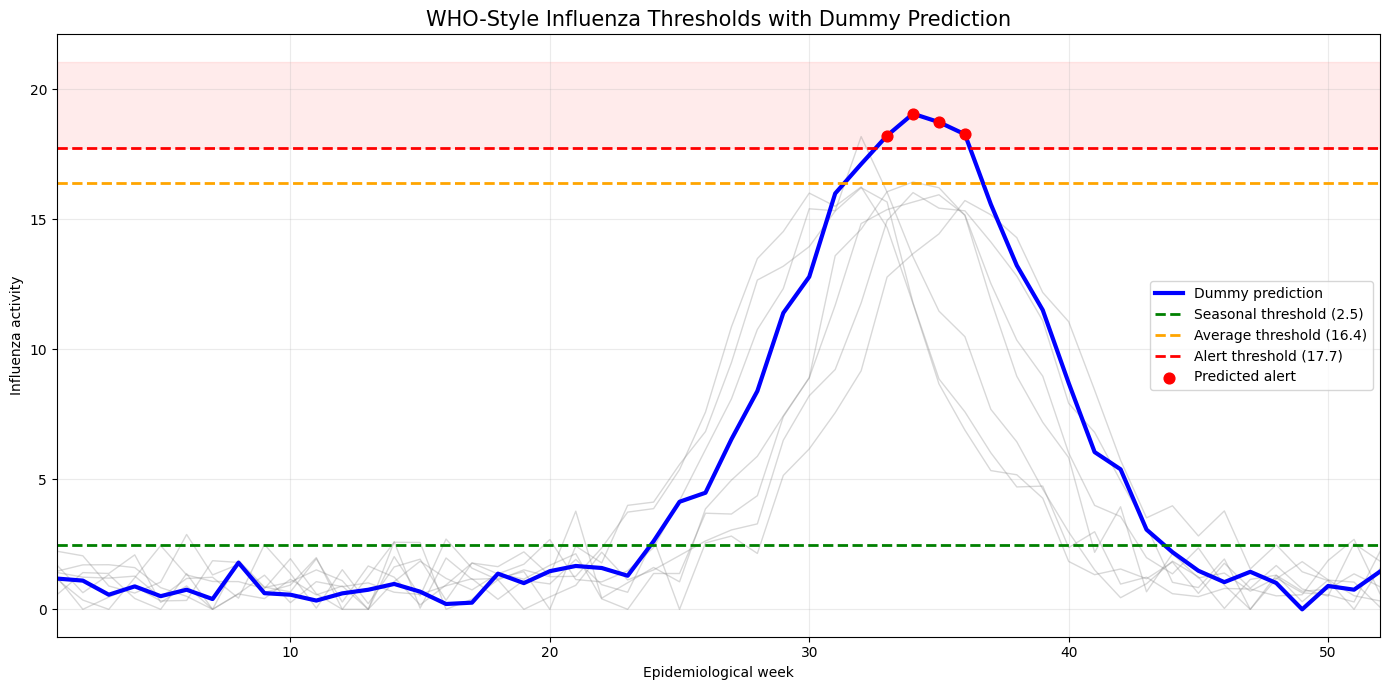

In [13]:
# ============================================================
# 12. PLOT HISTORICAL DATA
# ============================================================

plt.figure(figsize=(14, 7))

# Plot each historical season
for year in historical["year"].unique():

    data = historical[
        historical["year"] == year
    ]

    plt.plot(
        data["week"],
        data["value"],
        color="gray",
        alpha=0.30,
        linewidth=1
    )


# ============================================================
# 13. PLOT DUMMY PREDICTION
# ============================================================

plt.plot(
    predicted["week"],
    predicted["prediction"],
    color="blue",
    linewidth=3,
    label="Dummy prediction"
)


# ============================================================
# 14. PLOT THRESHOLDS
# ============================================================

plt.axhline(
    seasonal_threshold,
    color="green",
    linestyle="--",
    linewidth=2,
    label=f"Seasonal threshold ({seasonal_threshold:.1f})"
)

plt.axhline(
    average_threshold,
    color="orange",
    linestyle="--",
    linewidth=2,
    label=f"Average threshold ({average_threshold:.1f})"
)

plt.axhline(
    alert_threshold,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Alert threshold ({alert_threshold:.1f})"
)


# ============================================================
# 15. SHADE ALERT REGION
# ============================================================

plt.fill_between(
    future_weeks,
    alert_threshold,
    predicted["prediction"].max() + 2,
    color="red",
    alpha=0.08
)


# ============================================================
# 16. MARK PREDICTED ALERT POINTS
# ============================================================

plt.scatter(
    alert_weeks["week"],
    alert_weeks["prediction"],
    color="red",
    s=60,
    zorder=5,
    label="Predicted alert"
)


# ============================================================
# 17. FINAL PLOT FORMATTING
# ============================================================

plt.title(
    "WHO-Style Influenza Thresholds with Dummy Prediction",
    fontsize=15
)

plt.xlabel("Epidemiological week")
plt.ylabel("Influenza activity")

plt.xlim(1, 52)

plt.grid(
    alpha=0.25
)

plt.legend()

plt.tight_layout()

plt.show()
